In [1]:
import pandas as pd
import numpy as np
from src import run_experiment
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('../Data/app_train_eda.csv')

In [3]:
target = df['TARGET']

In [4]:
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = df.select_dtypes(exclude=['float64', 'int64']).columns
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [5]:
df = pd.concat([df[cat_cols], target], axis=1)

In [6]:
# Солвер 'saga' с penalty='elasticnet' очень долго сходится, поэтому сделаем пока чистую L2-регуляризацию
def log_reg_param_space(trial):
    return {
        "C": trial.suggest_float('C', 1e-3, 1e2, log=True),
        # "l1_ratio": trial.suggest_float('l1_ratio', 0, 1, step=0.1),
        # "penalty": trial.suggest_categorical('penalty', ['elasticnet']),
        # "solver": trial.suggest_categorical('solver', ['saga']),
        "max_iter": trial.suggest_int('max_iter', 100, 1000, step=100)
    }

[I 2026-04-30 13:54:36,899] Using an existing study with name 'LogisticRegression' instead of creating a new one.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/Users/uralgimazov/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    3.0s finished
[I 2026-04-30 13:54:40,000] Trial 7 finished with value: 0.626250203259668 and parameters: {'C': 0.07459343285726547, 'max_iter': 1000}. Best is trial 0 with value: 0.7426844349593199.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.6s remaining:    2.5s
/Users/uralgimazov/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns

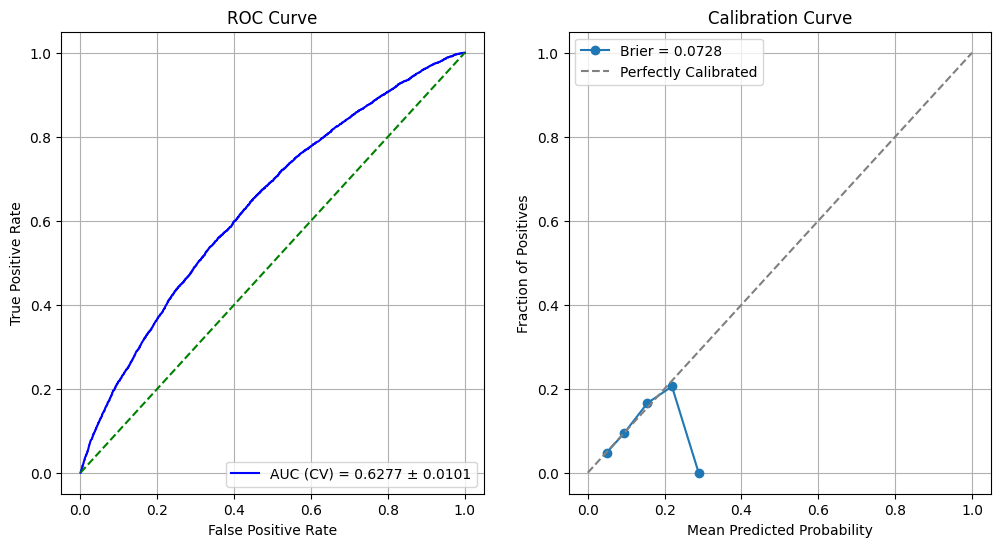

{'auc_mean_cv': np.float64(0.6277),
 'auc_std_cv': np.float64(0.0101),
 'brier_score': np.float64(0.0728)}

In [7]:
exp_name = f'check'

run_experiment(
    exp_name,
    LogisticRegression,
    log_reg_param_space,
    df,
    n_trials=1,
    cv_num=2
)